In [ ]:
import numpy as np
import pandas as pd
import matplotlib.psyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score


In [ ]:
# Charger les données
movies = pd.read_csv('IMDB-Movie-Data.csv')
movies = movies[['Title', 'Rating', 'Votes', 'Metascore']]
movies.head()


In [ ]:
# Remplacement des valeurs manquantes dans Metascore par la moyenne
movies['Metascore'] = pd.to_numeric(movies['Metascore'], errors='coerce')
movies['Metascore'].fillna(movies['Metascore'].mean(), inplace=True)



In [ ]:
# Normalisation des votes et du metascore
movies['Votes'] = (movies['Votes'] - movies['Votes'].min()) / (movies['Votes'].max() - movies['Votes'].min())
movies['Metascore'] = (movies['Metascore'] - movies['Metascore'].min()) / (movies['Metascore'].max() - movies['Metascore'].min())



In [ ]:
# Calcul du score basé sur le rating divisé par le nombre de votes
movies['adjusted_rating'] = movies['Rating'] / (movies['Votes'])



In [ ]:
# Création d'un score pondéré
movies['score'] = (movies['adjusted_rating'] * 0.5) + (movies['Metascore'] * 0.5)



In [ ]:
# Création de la variable cible
movies['sentiment'] = movies['score'].apply(lambda x: 1 if x > movies['score'].median() else 0)



In [ ]:
# Séparation en jeu d'entraînement et test
X_train, X_test, y_train, y_test = train_test_split(movies[['adjusted_rating', 'Votes', 'Metascore']], movies['sentiment'], test_size=0.2, random_state=42)



In [ ]:
# Modélisation avec Naïve Bayes
model = MultinomialNB()
model.fit(X_train, y_train)



MultinomialNB()

In [ ]:
# Prédictions
y_pred = model.predict(X_test)



In [ ]:
# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)



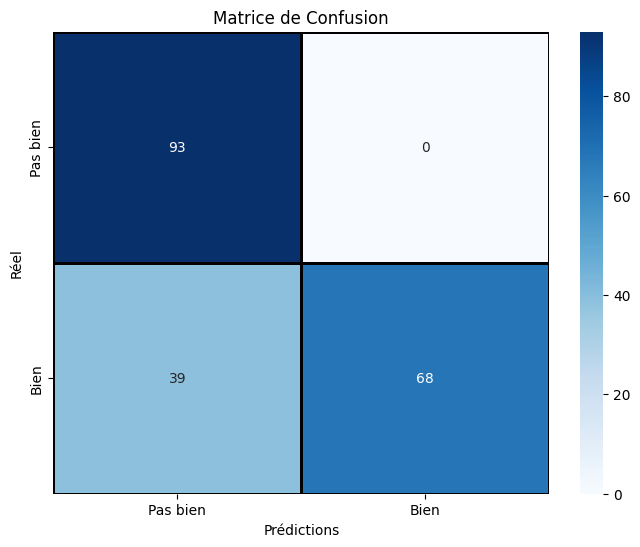

In [ ]:
# Affichage amélioré de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Pas bien", "Bien"], yticklabels=["Pas bien", "Bien"], linewidths=1, linecolor='black')
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de Confusion")
plt.show()



In [ ]:
# Calcul du F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2f}")


F1-score: 0.78


In [ ]:
# Calcul du recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")


Recall: 0.64


In [ ]:
# Menu interactif pour prédire la qualité d'un film
while True:
    print("\nMenu :")
    print("1. Choisir un film et voir s'il est bien ou pas")
    print("2. Quitter")

    choix = input("Entrez votre choix : ")

    if choix == "1":
        film_titre = input("Entrez le titre du film : ")

        if film_titre in movies['Title'].values:
            film = movies[movies['Title'] == film_titre]
            film_features = film[['adjusted_rating', 'Votes', 'Metascore']]
            prediction = model.predict(film_features)

            if prediction[0] == 1:
                print(f"Le film '{film_titre}' est considéré comme BIEN.")
            else:
                print(f"Le film '{film_titre}' est considéré comme PAS BIEN.")
        else:
            print("Film non trouvé dans la base de données.")

    elif choix == "2":
        print("Fermeture du programme.")
        break
    else:
        print("Choix invalide. Veuillez entrer 1 ou 2.")


Menu :
1. Choisir un film et voir s'il est bien ou pas
2. Quitter
Entrez votre choix : 1
Entrez le titre du film : Split
Le film 'Split' est considéré comme PAS BIEN.

Menu :
1. Choisir un film et voir s'il est bien ou pas
2. Quitter
Entrez votre choix : 1
Entrez le titre du film : Paint It Black
Le film 'Paint It Black' est considéré comme BIEN.

Menu :
1. Choisir un film et voir s'il est bien ou pas
2. Quitter
